# pjt_02_kjt

### 필요한 모듈

In [54]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### CSV 파일 불러오기

In [55]:
def file_open_by_numpy():
    # np.loadtxt(구분자 = ',', 데이터 타입: string)
    np_arr = np.loadtxt('archive/NFLX.CSV', delimiter=",", encoding='cp949', dtype=str)
    return np_arr
arr = file_open_by_numpy()
print(type(arr))

<class 'numpy.ndarray'>


### 컬럼과 데이터 분리

In [56]:
header = arr[0]
data = arr[1:]
print(header)
print(data[:3])

['Date' 'Open' 'High' 'Low' 'Close' 'Adj Close' 'Volume']
[['2018-02-05' '262.000000' '267.899994' '250.029999' '254.259995'
  '254.259995' '11896100']
 ['2018-02-06' '247.699997' '266.700012' '245.000000' '265.720001'
  '265.720001' '12595800']
 ['2018-02-07' '266.579987' '272.450012' '264.329987' '264.559998'
  '264.559998' '8981500']]


### 컬럼 선별

In [57]:
#selected = data[:, 0:5]
#print(selected[:3])
need_cols = ['Date','Open','High','Low','Close']
idx = [list(header).index(c) for c in need_cols]
selected =data[:,idx]
print(selected[:3])

[['2018-02-05' '262.000000' '267.899994' '250.029999' '254.259995']
 ['2018-02-06' '247.699997' '266.700012' '245.000000' '265.720001']
 ['2018-02-07' '266.579987' '272.450012' '264.329987' '264.559998']]


### pandas 적용

In [58]:
df = pd.DataFrame(selected, columns=need_cols)
df

,Date,Open,High,Low,Close
0,2018-02-05,262.000000,267.899994,250.029999,254.259995
1,2018-02-06,247.699997,266.700012,245.000000,265.720001
2,2018-02-07,266.579987,272.450012,264.329987,264.559998
3,2018-02-08,267.079987,267.619995,250.000000,250.100006
4,2018-02-09,253.850006,255.800003,236.110001,249.470001
...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006


### 데이터 필터링

In [59]:
df['Date'] = pd.to_datetime(df['Date']) ## 'Date' 를 날짜 타입으로 변환
#df.dtypes #출력
df_2021 = df[df['Date'] >= '2021-01-01'] ## 2021 이후 데이터만 필터링
print(df_2021.head())
print(df_2021.tail())

          Date        Open        High         Low       Close
733 2021-01-04  539.000000  540.799988  515.090027  522.859985
734 2021-01-05  521.549988  526.780029  515.890015  520.799988
735 2021-01-06  511.970001  513.099976  499.500000  500.489990
736 2021-01-07  508.279999  516.440002  506.420013  508.890015
737 2021-01-08  511.309998  513.239990  504.510010  510.399994
           Date        Open        High         Low       Close
1004 2022-01-31  401.970001  427.700012  398.200012  427.140015
1005 2022-02-01  432.959991  458.480011  425.540009  457.130005
1006 2022-02-02  448.250000  451.980011  426.480011  429.480011
1007 2022-02-03  421.440002  429.260010  404.279999  405.600006
1008 2022-02-04  407.309998  412.769989  396.640015  410.170013


### pandas에 적용

In [60]:
df['Date'] = pd.to_datetime(df['Date']) #Date 컬럼을 날짜로 변환
df_2021 = df[df['Date'] >= '2021-01-01'] #2021년 이후 데이터만 필터링
df_2021.head()#확인용

,Date,Open,High,Low,Close
733,2021-01-04,539.000000,540.799988,515.090027,522.859985
734,2021-01-05,521.549988,526.780029,515.890015,520.799988
735,2021-01-06,511.970001,513.099976,499.500000,500.489990
736,2021-01-07,508.279999,516.440002,506.420013,508.890015
737,2021-01-08,511.309998,513.239990,504.510010,510.399994


### 데이터 타입 숫자변환

In [61]:
df_2021['Close'] =df_2021['Close'].astype(float)

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_12096\551779463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2021['Close'] =df_2021['Close'].astype(float)


### Pandas 그래프 그리기

<Axes: title={'center': 'NFLX Close Price (2021~)'}, xlabel='Date'>

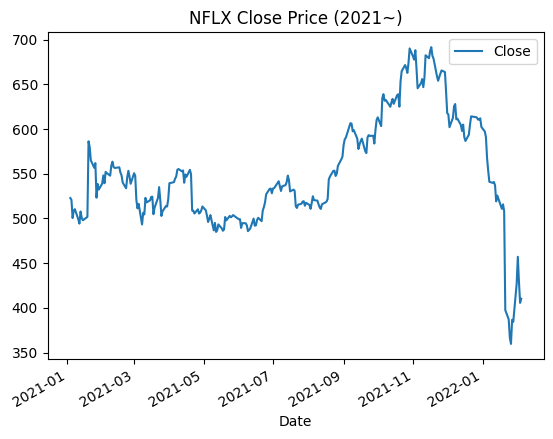

In [62]:
df_2021.plot(
    x = 'Date',
    y = 'Close',
    title='NFLX Close Price (2021~)'
)

### 데이터의 최대/최소 값

In [63]:
max_price = df_2021['Close'].max()
min_price = df_2021['Close'].min()
print("최고 종가:", max_price)
print("최저 종가:", min_price)

최고 종가: 691.690002
최저 종가: 359.700012


### 평균 구하기 + 그래프에 넣기

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_12096\2727272872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2021['Month'] = df_2021['Date'].dt.to_period('M') #월별 그룹화


<Axes: title={'center': 'Monthly Average Close Price (2021~)'}, xlabel='Month'>

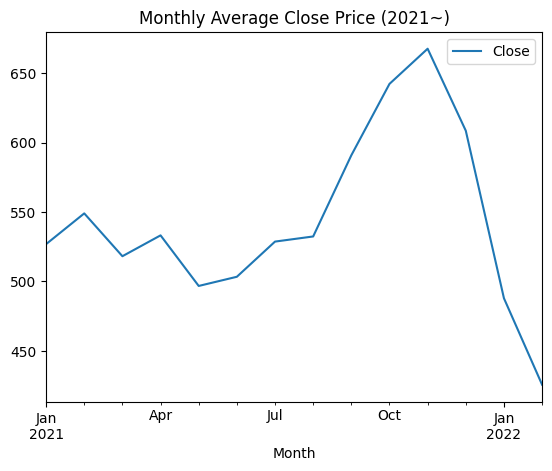

In [64]:
df_2021['Month'] = df_2021['Date'].dt.to_period('M') #월별 그룹화
monthly_avg = (                             #월별 평균 종가 계산 
    df_2021                              
    .groupby('Month')['Close']           # groupby() : () 안의 값의 값이 같은 애들끼리 묶는다 ,[close] 컬럼만 보겠다           
    .mean()                              # mean() : 평균 구하기
    .reset_index()                       #.reset_index() 깔끔한 dataFrame
)
monthly_avg.plot(
    x = 'Month',
    y = 'Close',
    title= 'Monthly Average Close Price (2021~)' 
)


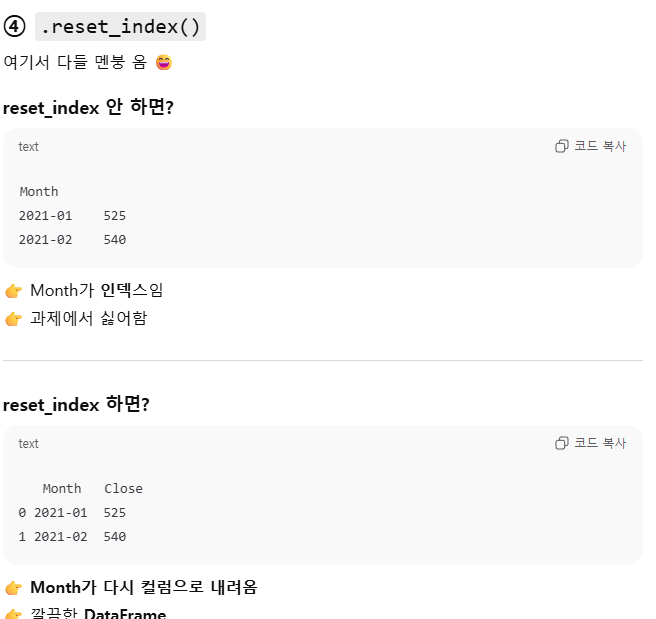

### 복합 데이터 필터링

<Axes: title={'center': 'High, Low, and Close Prices since January 2022'}, xlabel='Month'>

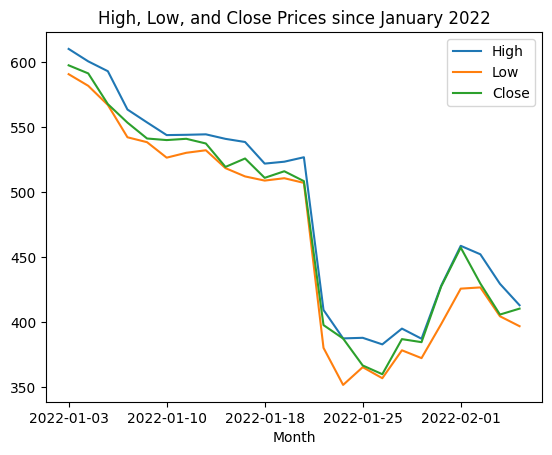

In [68]:
# 1. Date 컬럼을 datetime 타입으로 변환
df['Date'] = pd.to_datetime(df['Date'])

# 2. High, Low, Close 컬럼을 숫자(float)로 변환
#    (문자열 상태면 평균/최대/최소 계산 불가)
df[['High', 'Low', 'Close']] = df[['High', 'Low', 'Close']].apply(
    pd.to_numeric, errors='coerce'
)

# 3. 2022년 이후 데이터만 필터링 (복사본 생성)
df_2022 = df.loc[df['Date'] >= '2022-01-01'].copy()

# 4. 월 단위 그룹화를 위한 Month 컬럼 생성
df_2022['Month'] = df_2022['Date'].dt.to_period('D')

# 5. 월별 최고가(High), 최저가(Low), 평균 종가(Close) 계산
monthly_prices = (
    df_2022
    .groupby('Month')
    .agg({
        'High': 'max',    # 월별 최고가
        'Low': 'min',     # 월별 최저가
        'Close': 'mean'   # 월별 평균 종가
    })
    .reset_index()        # Month를 인덱스 → 컬럼으로
    .sort_values('Month') # 월 순서대로 정렬
)

# 6. Period 타입을 문자열로 변환 (그래프 x축 표시용)
monthly_prices['Month'] = monthly_prices['Month'].astype(str)

# 7. 월별 최고 / 최저 / 종가를 하나의 선 그래프로 시각화
monthly_prices.plot(
    x='Month',
    y=['High', 'Low', 'Close'],
    title='High, Low, and Close Prices since January 2022'
)
